In [22]:
import warnings


In [5]:
from pathlib import Path
import os

IMAGES_PATH = Path("../resources/cloud-images/NASA_GLOBE_CD/downloaded_images")

def index_labeled_images(images_path=IMAGES_PATH):
    cloud_labels = []
    images_path = Path(images_path)
    labeled_images = {}
    if not images_path.exists():
        return labeled_images

    for cloud_dir in sorted(p for p in images_path.iterdir() if p.is_dir()):
        count = 0
        for img_path in sorted(p for p in cloud_dir.iterdir() if p.is_file()):
            if count > 3000:
                break
            labeled_images[img_path.name] = {
                "label": cloud_dir.name,
                "path": str(img_path)
            }
            count += 1

    return labeled_images, cloud_labels

In [6]:
labeled_images, cloud_labels = index_labeled_images()

In [8]:
print(len(labeled_images))

30559


In [10]:
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tqdm.auto import tqdm

def extract_labels(labeled_images):
    import os  # Ensure os is imported for path validation
    images = []
    labels = []
    for (i, image_name) in tqdm(enumerate(labeled_images), total=len(labeled_images)):
        path = labeled_images[image_name]['path']

        # Check if the file exists before attempting to read
        if not os.path.exists(path):
            print(f"Error: File does not exist at path: {path}")
            continue

        # Attempt to read the image
        image = cv2.imread(path)
        if image is None:
            print(f"Error: Unable to read image at path: {path}")
            continue

        try:
            # Convert to grayscale and resize
            image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            image = cv2.resize(image, (64, 64))
            images.append(image)

            # Append the label
            label = labeled_images[image_name]['label']
            labels.append(label)
        except Exception as e:
            print(f"Error processing image {image_name}: {e}")
            continue

    return np.array(images), np.array(labels)

In [11]:
images, labels = extract_labels(labeled_images)

100%|██████████| 30559/30559 [04:30<00:00, 112.81it/s]


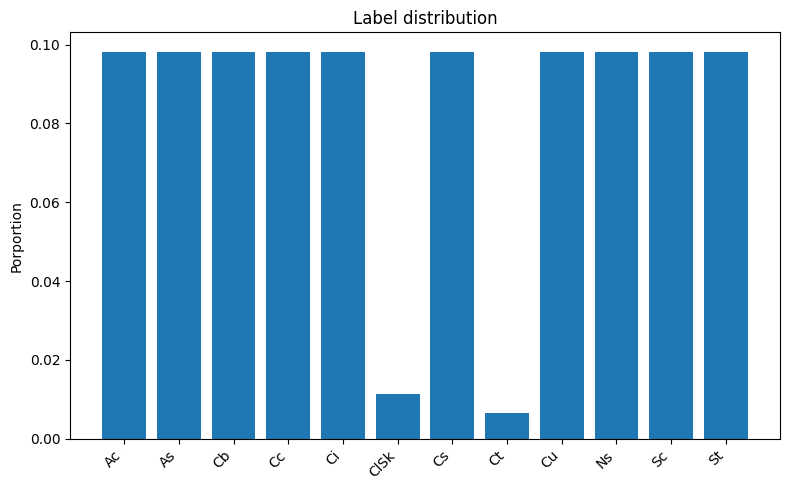

In [12]:
import matplotlib.pyplot as plt
from collections import Counter

# labels must be a 1D array or list of class names
label_counts = Counter(labels)
classes = list(label_counts.keys())
counts = np.array(list(label_counts.values()))
props = counts / counts.sum()

plt.figure(figsize=(8, 5))
plt.bar(classes, props)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Porportion")
plt.title("Label distribution")
plt.tight_layout()
plt.show()

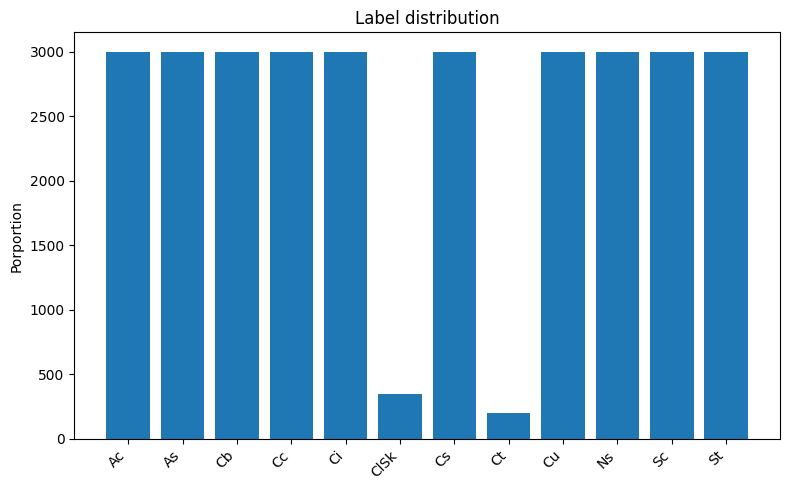

In [13]:
import matplotlib.pyplot as plt
from collections import Counter

# labels must be a 1D array or list of class names
label_counts = Counter(labels)
classes = list(label_counts.keys())
counts = np.array(list(label_counts.values()))

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Porportion")
plt.title("Label distribution")
plt.tight_layout()
plt.show()

In [14]:
print(counts)

[3001 3001 3001 3001 3001  349 3001  200 3001 3001 3001 3001]
